# Exploratory Data Analysis: Stroke Prediction Dataset

## 1. Objective

This notebook explores the Stroke Prediction Dataset to understand:
- patient characteristics
- data quality issues
- distributions of clinical variables
- relationships between patient features and stroke outcomes

The findings from this analysis will guide preprocessing and machine learning model development.

In [1]:
#import kagglehub

# Download latest version
#path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")
#print("Path to dataset files:", path) # then move to the data folder

In [2]:
import sys

print(sys.executable)

c:\Year 2026\2026 Git project\project1---stroke-prediction\.venv\Scripts\python.exe


## 2. Import libraries

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Check if it's in the correct working directory
os.getcwd()

'c:\\Year 2026\\2026 Git project\\project1---stroke-prediction\\notebooks'

## 3. Load dataset

In [5]:
data_path = "../data/healthcare-dataset-stroke-data.csv"

df = pd.read_csv(data_path)
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# 4. Dataset overview

In [6]:
df.shape

(5110, 12)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [8]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [9]:
df.describe(include="object")

C:\Users\12498\AppData\Local\Temp\ipykernel_67020\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,gender,ever_married,work_type,Residence_type,smoking_status
count,5110,5110,5110,5110,5110
unique,3,2,5,2,4
top,Female,Yes,Private,Urban,never smoked
freq,2994,3353,2925,2596,1892


# 5. Data quality assessment

In [10]:
df.isnull().sum() # Found that there are 201 missing values in the bmi columns.

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

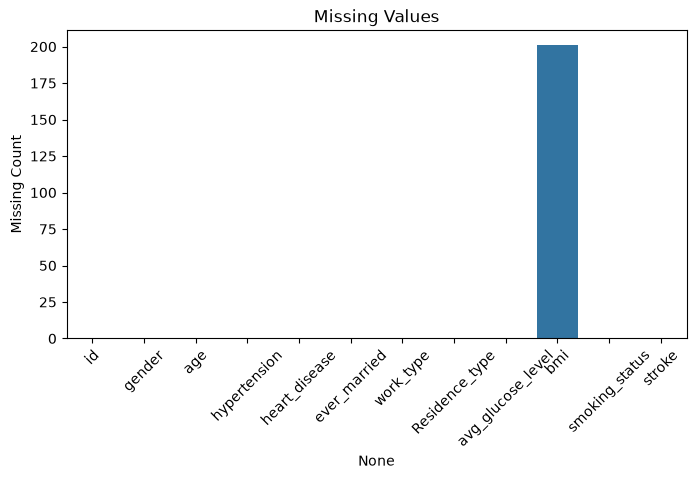

In [11]:
# plot all variables wit missing values
plt.figure(figsize=(8,4))

sns.barplot(
    x=df.isnull().sum().index,
    y=df.isnull().sum().values
)

plt.xticks(rotation=45)
plt.ylabel("Missing Count")
plt.title("Missing Values")
plt.show()

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
# print out the unique values for each categorical variable
for col in df.select_dtypes(include="object"):
    print(col)
    print(df[col].unique())
    print()

gender
<StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str

ever_married
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

work_type
<StringArray>
['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked']
Length: 5, dtype: str

Residence_type
<StringArray>
['Urban', 'Rural']
Length: 2, dtype: str

smoking_status
<StringArray>
['formerly smoked', 'never smoked', 'smokes', 'Unknown']
Length: 4, dtype: str



C:\Users\12498\AppData\Local\Temp\ipykernel_67020\1455550064.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object"):


# 6. Univariate analysis

In [14]:
continuous_cols = [
    "age",
    "avg_glucose_level",
    "bmi"
]

categorical_cols = [
    "gender",
    "hypertension",
    "heart_disease",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status",
    "stroke"
]

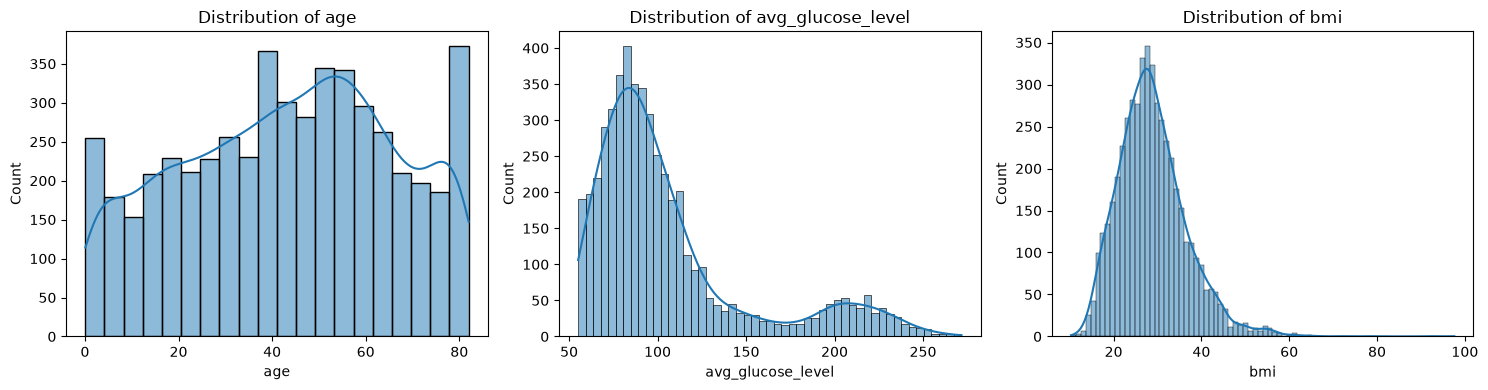

In [15]:
# plot the distribution of continuous variables
fig, axes = plt.subplots(
    nrows=1, 
    ncols=len(continuous_cols), 
    figsize=(15, 4)
)

for col, ax in zip(continuous_cols, axes):
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        ax=ax
    )
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

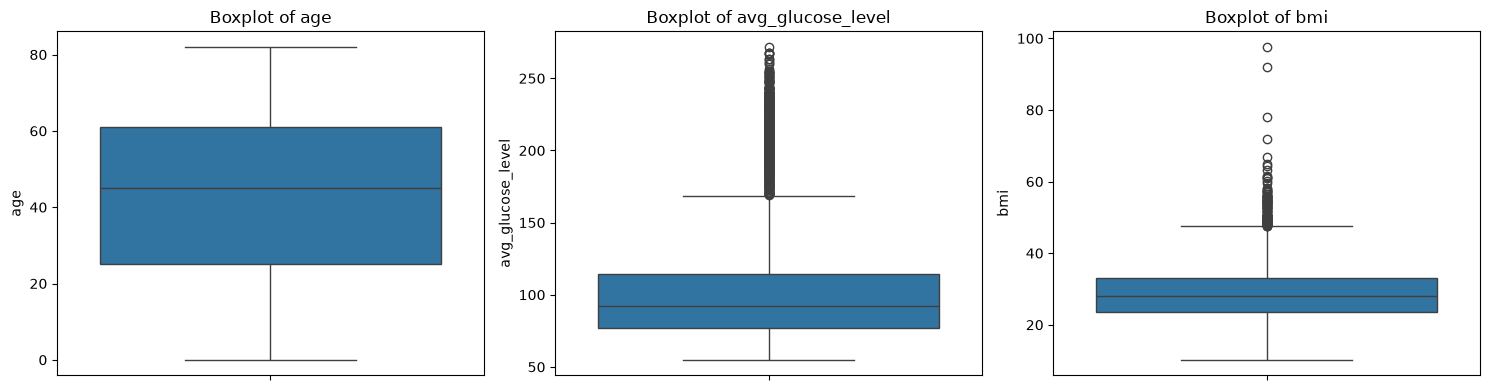

In [16]:
# plot the boxplots of continuous variables
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(continuous_cols),
    figsize=(15,4)
)

for col, ax in zip(continuous_cols, axes):
    sns.boxplot(
        data=df,
        y=col,
        ax=ax
    )
    ax.set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

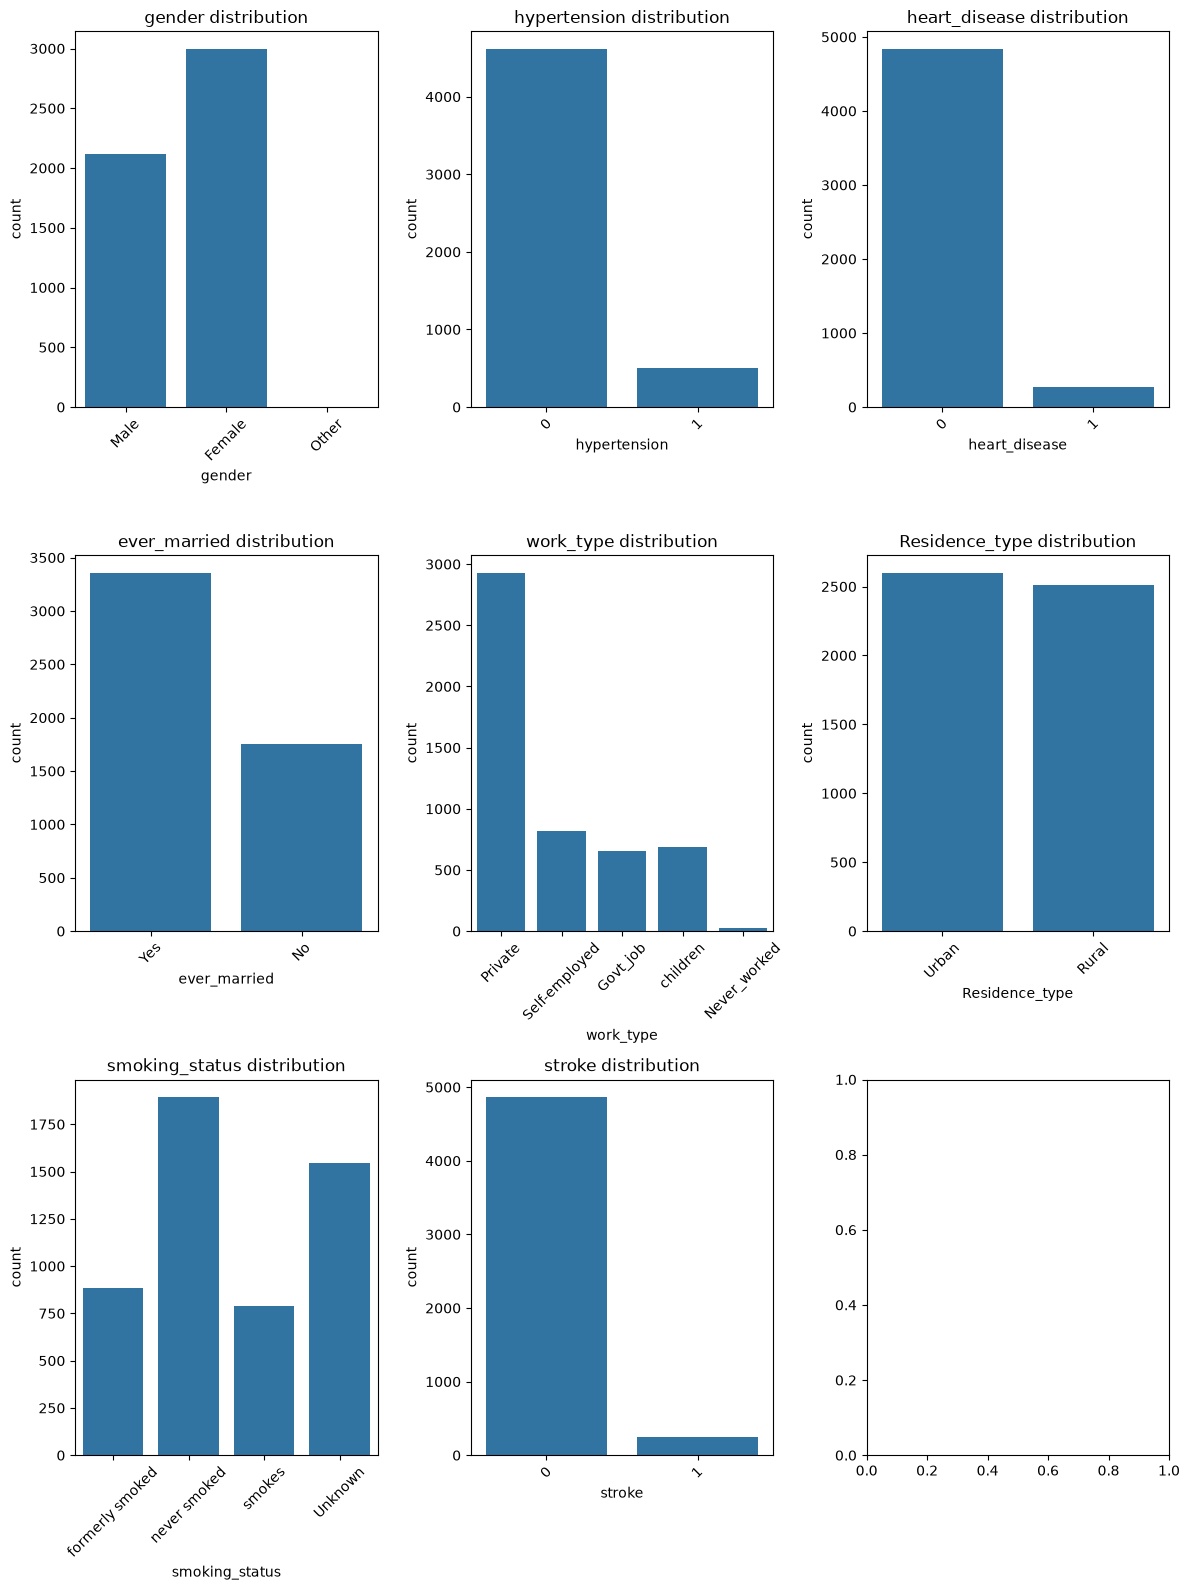

In [17]:
# plot the distribution of categorical variables
fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(12,16)
)

axes = axes.flatten()

for col, ax in zip(categorical_cols, axes):
    sns.countplot(
        data=df,
        x=col,
        ax=ax
    )
    ax.set_title(f"{col} distribution")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Stroke Outcome Distribution

The dataset shows a highly imbalanced outcome distribution, where stroke-positive cases represent a small proportion of observations.

In [18]:
stroke_dist = pd.DataFrame({
    "Count": df["stroke"].value_counts(),
    "Percentage": df["stroke"].value_counts(normalize=True) 
})

stroke_dist

,Count,Percentage
stroke,,
0,4861,0.951272
1,249,0.048728


# 7. Bivariate analysis

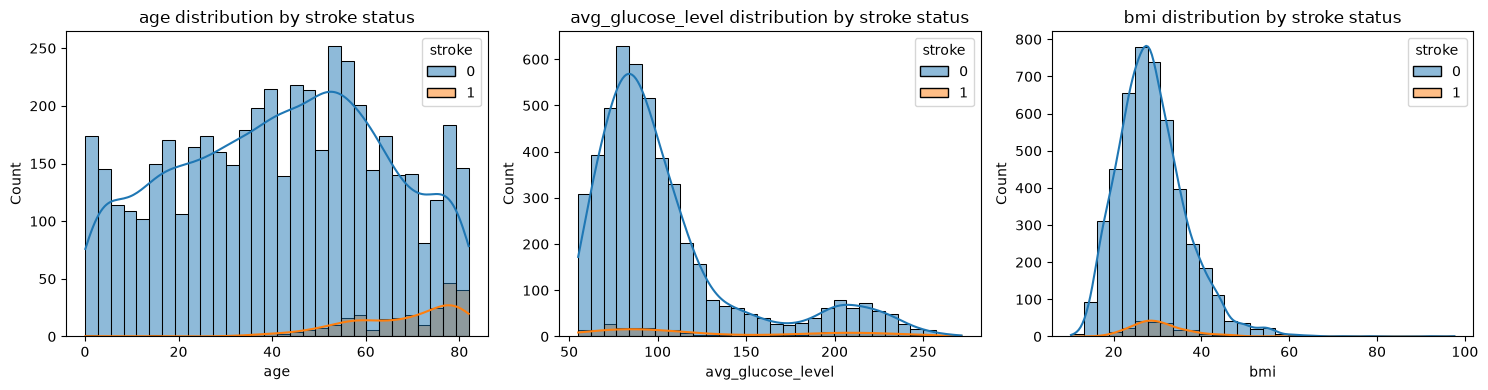

In [ ]:
# plot the distribution of continuous variables by stroke status 
fig, axes = plt.subplots(
    nrows=1, 
    ncols=len(continuous_cols), 
    figsize=(15, 4)
)

for col, ax in zip(continuous_cols, axes):
    sns.histplot(
        data=df,
        x=col,
        hue="stroke",
        bins=30,
        kde=True,
        ax=ax
    )
    ax.set_title(f"{col} distribution by stroke status")

plt.tight_layout()
plt.show()

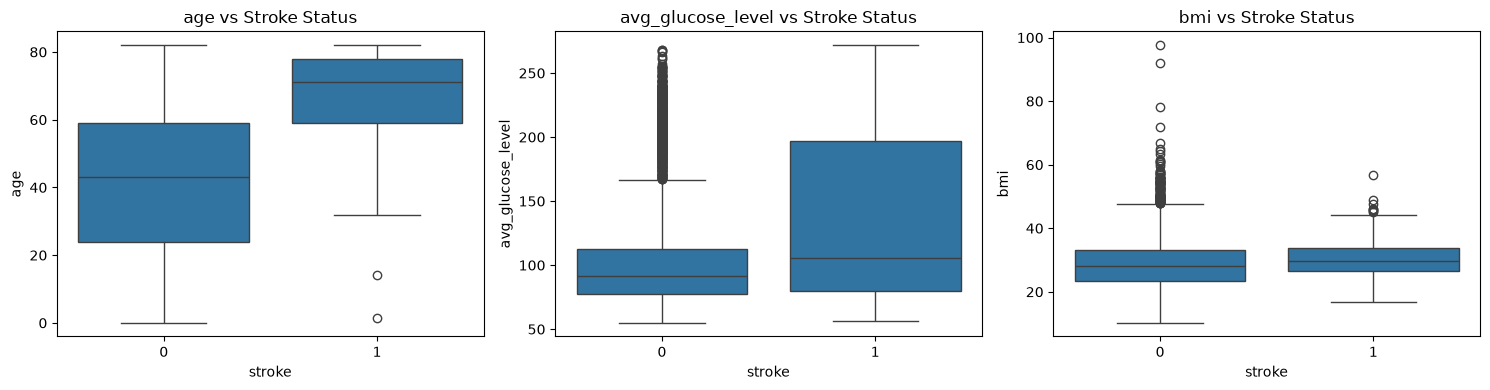

In [31]:
# plot the boxplots of continuous variables by stroke status 
fig, axes = plt.subplots(
    nrows=1, 
    ncols=len(continuous_cols), 
    figsize=(15, 4)
)

for col, ax in zip(continuous_cols, axes):
    sns.boxplot(
        data=df,
        x="stroke",
        y=col,
        ax=ax
    )
    ax.set_title(f"{col} vs Stroke Status")

plt.tight_layout()
plt.show()

In [22]:
pd.crosstab(
    df["hypertension"],
    df["stroke"],
    normalize="index"
)

stroke,0,1
hypertension,,
0,0.960321,0.039679
1,0.867470,0.132530


In [23]:
pd.crosstab(
    df["heart_disease"],
    df["stroke"],
    normalize="index"
)

stroke,0,1
heart_disease,,
0,0.958213,0.041787
1,0.829710,0.170290


## 8. Correlation analysis

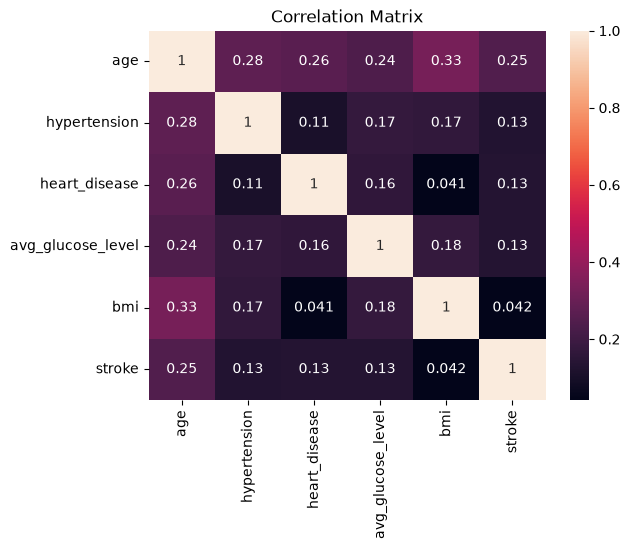

In [26]:
numeric_cols = [
    "age",
    "hypertension",
    "heart_disease",
    "avg_glucose_level",
    "bmi",
    "stroke"
]

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True
)

plt.title("Correlation Matrix")
plt.show()


# 8. Initial findings / EDA summary

## EDA Summary

Key observations:

1. The dataset contains 5,110 patient records and 11 predictors.
2. Stroke outcomes are highly imbalanced, (~5% positive cases).
3. BMI contains missing values requiring preprocessing.
4. Age, hypertension, heart disease, and glucose level show potential associations with stroke outcome.
5. Due to class imbalance, ,odel evaluation should prioritize sensitivity, specificity, and ROC-AUC rather than accuracy alone.